<a href="https://colab.research.google.com/github/Victoriaaahh/Calculo_Numerico/blob/main/Atividade1_CN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Atividade 1 -  Maria Luíza Margarido Balbo e Victoria Ayumi Kose**


---



**Divisão de Tarefas:**

Questões Ímpares feitas por: Victoria Ayumi Kose

Questões Pares feitas por: Maria Luiza Margarido Balbo

**1) Objetivos**

• calcular erros absoluto, relativo e percentual;

• distinguir truncamento de arredondamento;

• observar a propagação dos erros em cálculos de pressão e vazão;

• produzir gráficos que comuniquem a evolução dos erros;

• explicar por que pequenas variações geométricas podem alterar intensamente o escoamento em um nanocateter.

**2) Conceitos necessários**

Se $x$ é o valor de referência e $\widetilde{x}$ é uma aproximação, use

$$ E_a = |x - \widetilde{x}| \hspace{3cm} \text{erro absoluto,} \tag{1} $$

$$ E_r = \frac{|x - \widetilde{x}|}{|x|} \hspace{3cm} \text{erro relativo,} \tag{2} $$

$$ E_\% = 100E_r \hspace{3.4cm} \text{erro percentual.} \tag{3} $$

Para $n$ casas decimais:

* **arredondamento:** considera o primeiro algarismo descartado;
* **truncamento:** simplesmente elimina os algarismos posteriores à casa escolhida.

No Python, `round(x,n)` pode ser usado para arredondar. Para truncar sem arredondar, implemente

$$ x_{\text{trunc}} = \frac{\text{trunc}(10^n x)}{10^n}. $$

**3) Parte A – truncamento e arredondamento**

Considere os valores

x1 = 3,14159265, x2 = 98,76543, x3 = 0,00498765.

Para cada valor, use n = 0, 1, 2, 3, 4 casas decimais e:
1. calcule a aproximação por truncamento e por arredondamento;
2. calcule Ea, Er e E%;
3. organize os resultados em uma tabela;
4. faça um gráfico em escala logarítmica de Ea em função de n;
5. responda: arredondar sempre gera erro menor ou igual ao truncamento? Justifique com os
resultados.

### Resultados para x1 = 3.14159265
|   n |   Truncamento |     Ea (T) |      Er (T) |     E% (T) |   Arredondamento |     Ea (A) |      Er (A) |      E% (A) |
|----:|--------------:|-----------:|------------:|-----------:|-----------------:|-----------:|------------:|------------:|
|   0 |        3      | 0.141593   | 0.0450703   | 4.50703    |           3      | 0.141593   | 0.0450703   | 4.50703     |
|   1 |        3.1    | 0.0415927  | 0.0132394   | 1.32394    |           3.1    | 0.0415927  | 0.0132394   | 1.32394     |
|   2 |        3.14   | 0.00159265 | 0.000506956 | 0.0506956  |           3.14   | 0.00159265 | 0.000506956 | 0.0506956   |
|   3 |        3.141  | 0.00059265 | 0.000188646 | 0.0188646  |           3.142  | 0.00040735 | 0.000129664 | 0.0129664   |
|   4 |        3.1415 | 9.265e-05  | 2.94914e-05 | 0.00294914 |           3.1416 | 7.35e-06   | 2.33958e-06 | 0.000233958 |


### Resultados para x2 = 98.76543
|   n |   Truncamento |   Ea (T) |      Er (T) |      E% (T)

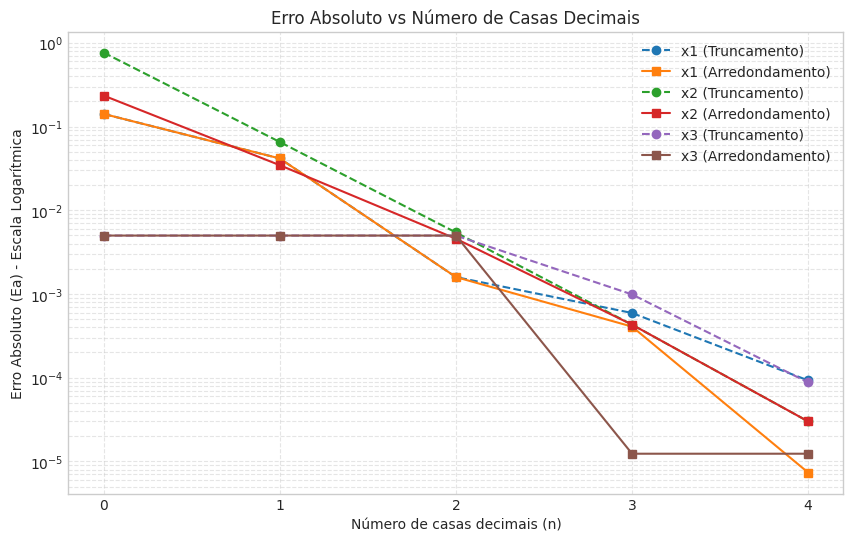

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# definindo funções
def truncar(x, n):
    return math.trunc(x * (10**n)) / (10**n)

def calcular_erros(x, x_aprox):
    ea = abs(x - x_aprox)
    er = ea / abs(x)
    ep = 100 * er
    return ea, er, ep

# Valores
valores_x = {
    'x1': 3.14159265,
    'x2': 98.76543,
    'x3': 0.00498765
}
valores_n = [0, 1, 2, 3, 4]

resultados = []

for nome, x in valores_x.items():
    for n in valores_n:
        x_truncado = truncar(x, n)
        ea_t, er_t, ep_t = calcular_erros(x, x_truncado)

        x_arredondado = round(x, n)
        ea_a, er_a, ep_a = calcular_erros(x, x_arredondado) # Mudança de sufixos _r para _a (Arredondamento)

        resultados.append({
            'Valor': nome,
            'x_ref': x,
            'n': n,
            'Truncamento': x_truncado,
            'Ea (T)': ea_t,
            'Er (T)': er_t,
            'E% (T)': ep_t,
            'Arredondamento': x_arredondado,
            'Ea (A)': ea_a,
            'Er (A)': er_a,
            'E% (A)': ep_a
        })

df = pd.DataFrame(resultados)

# 1. Tabelas
for nome in valores_x.keys():
    print(f"### Resultados para {nome} = {valores_x[nome]}")
    df_filtrado = df[df['Valor'] == nome].drop(columns=['Valor', 'x_ref'])
    print(df_filtrado.to_markdown(index=False))
    print("\n")

# 2. Gráfico
plt.figure(figsize=(10, 6))

for nome in valores_x.keys():
    df_filtrado = df[df['Valor'] == nome]
    plt.plot(df_filtrado['n'], df_filtrado['Ea (T)'], marker='o', linestyle='--', label=f'{nome} (Truncamento)')
    plt.plot(df_filtrado['n'], df_filtrado['Ea (A)'], marker='s', linestyle='-', label=f'{nome} (Arredondamento)')

plt.yscale('log')
plt.xlabel('Número de casas decimais (n)')
plt.ylabel('Erro Absoluto (Ea) - Escala Logarítmica')
plt.title('Erro Absoluto vs Número de Casas Decimais')
plt.xticks(valores_n)
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.savefig('grafico_erros.png')
print("Gráfico salvo como 'grafico_erros.png'")

**3.5) responda: arredondar sempre gera erro menor ou igual ao truncamento? Justifique com os resultados.**

Sim, o arredondamento sempre gera um erro menor ou igual ao truncamento. Como o método de arredondamento escolhe o valor representável mais próximo na reta numérica, o erro absoluto máximo gerado é limitado a $0,5 \cdot 10^{-n}$, enquanto o truncamento apenas descarta os dígitos, permitindo que o erro chegue a quase $10^{-n}$. Observando os resultados calculados, o erro entre os métodos é exatamente igual quando o primeiro algarismo descartado é menor que 5; por exemplo, para $x_1 = 3,14159265$ com $n=2$, tanto o truncamento quanto o arredondamento resultam em $3,14$, gerando o mesmo Erro Absoluto ($E_a \approx 0,001593$). No entanto, quando o algarismo descartado é maior ou igual a 5, o arredondamento minimiza a diferença e apresenta um erro estritamente menor. Isso fica evidente ao avaliar o mesmo valor $x_1$ com $n=3$ casas decimais: o truncamento resulta em $3,141$ com um erro maior ($E_a \approx 0,000593$), enquanto o arredondamento ajusta a aproximação para $3,142$, entregando um erro menor ($E_a \approx 0,000407$). Dessa forma, não existe cenário em que o truncamento seja mais próximo do valor real, confirmando que o erro do arredondamento será sempre menor ou igual.

**4) Parte B – medidas de pressão arterial**

--- Estatísticas ---
|              |   Média |   Mínimo |   Máximo |   Amplitude |   Desvio Padrão |
|:-------------|--------:|---------:|---------:|------------:|----------------:|
| Originais    |  121.12 |    119.8 |    122.4 |         2.6 |        0.833733 |
| Arredondados |  121.1  |    120   |    122   |         2   |        0.875595 |
| Truncados    |  120.7  |    119   |    122   |         3   |        0.948683 |

--- Erros ---
|              |   Média Aproximada |   Erro Absoluto (Ea) |   Erro Relativo (Er) |   Erro Percentual (E%) |
|:-------------|-------------------:|---------------------:|---------------------:|-----------------------:|
| Arredondados |              121.1 |                 0.02 |          0.000165125 |              0.0165125 |
| Truncados    |              120.7 |                 0.42 |          0.00346764  |              0.346764  |

Gráficos salvos como 'graficos_pressao.png'


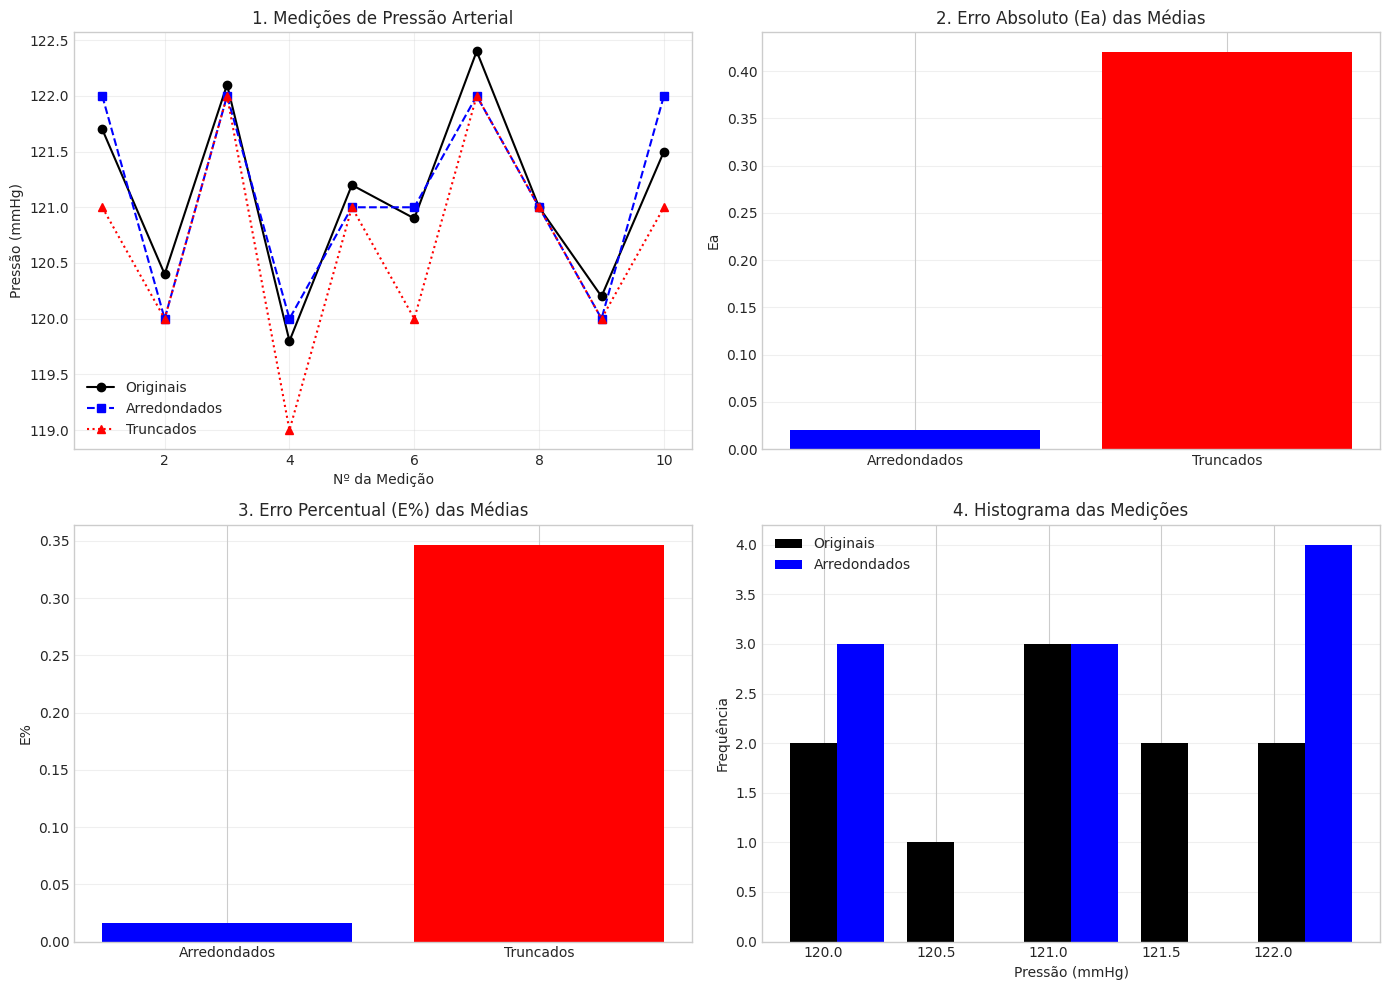

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dados
originais = np.array([121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5])

# Séries
# Utilizando arredondamento clássico (x >= 0.5 sobe) para evitar banker's rounding do numpy
arredondados = np.floor(originais + 0.5)
truncados = np.trunc(originais)

# Função para estatísticas
def calc_stats(data):
    return {
        'Média': np.mean(data),
        'Mínimo': np.min(data),
        'Máximo': np.max(data),
        'Amplitude': np.max(data) - np.min(data),
        'Desvio Padrão': np.std(data, ddof=1) # Amostral
    }

stats_orig = calc_stats(originais)
stats_arr = calc_stats(arredondados)
stats_trunc = calc_stats(truncados)

# Erros da média
media_ref = stats_orig['Média']

def calc_errors(aprox, ref):
    ea = np.abs(ref - aprox)
    er = ea / np.abs(ref)
    ep = er * 100
    return ea, er, ep

erros_arr = calc_errors(stats_arr['Média'], media_ref)
erros_trunc = calc_errors(stats_trunc['Média'], media_ref)

# Montando DataFrames para exibição
df_stats = pd.DataFrame([stats_orig, stats_arr, stats_trunc], index=['Originais', 'Arredondados', 'Truncados'])

df_erros = pd.DataFrame({
    'Média Aproximada': [stats_arr['Média'], stats_trunc['Média']],
    'Erro Absoluto (Ea)': [erros_arr[0], erros_trunc[0]],
    'Erro Relativo (Er)': [erros_arr[1], erros_trunc[1]],
    'Erro Percentual (E%)': [erros_arr[2], erros_trunc[2]]
}, index=['Arredondados', 'Truncados'])

print("--- Estatísticas ---")
print(df_stats.to_markdown())
print("\n--- Erros ---")
print(df_erros.to_markdown())

# Gráficos
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# 1. Gráfico das medições (O texto menciona 4 séries, mas lista 3. Plotaremos as 3)
x = np.arange(1, 11)
axs[0, 0].plot(x, originais, 'ko-', label='Originais')
axs[0, 0].plot(x, arredondados, 'bs--', label='Arredondados')
axs[0, 0].plot(x, truncados, 'r^:', label='Truncados')
axs[0, 0].set_title('1. Medições de Pressão Arterial')
axs[0, 0].set_xlabel('Nº da Medição')
axs[0, 0].set_ylabel('Pressão (mmHg)')
axs[0, 0].legend()
axs[0, 0].grid(True, alpha=0.3)

# 2. Gráfico de barras Ea
axs[0, 1].bar(['Arredondados', 'Truncados'], [erros_arr[0], erros_trunc[0]], color=['blue', 'red'])
axs[0, 1].set_title('2. Erro Absoluto (Ea) das Médias')
axs[0, 1].set_ylabel('Ea')
axs[0, 1].grid(axis='y', alpha=0.3)

# 3. Gráfico de barras E%
axs[1, 0].bar(['Arredondados', 'Truncados'], [erros_arr[2], erros_trunc[2]], color=['blue', 'red'])
axs[1, 0].set_title('3. Erro Percentual (E%) das Médias')
axs[1, 0].set_ylabel('E%')
axs[1, 0].grid(axis='y', alpha=0.3)

# 4. Histograma
axs[1, 1].hist([originais, arredondados], bins=5, label=['Originais', 'Arredondados'], color=['black', 'blue'])
axs[1, 1].set_title('4. Histograma das Medições')
axs[1, 1].set_xlabel('Pressão (mmHg)')
axs[1, 1].set_ylabel('Frequência')
axs[1, 1].legend()
axs[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('graficos_pressao.png')
print("\nGráficos salvos como 'graficos_pressao.png'")

**4) Explique se a representação inteira é suficiente para preservar a média e a variabilidade desta pequena amostra. Não faça interpretação médica dos valores.**

A representação inteira não é totalmente suficiente para preservar as características da amostra, pois a perda das casas decimais degrada a capacidade de descrever flutuações sutis no conjunto de dados. Em relação à preservação da média, o método de arredondamento consegue manter a estabilidade do valor central, aproximando a média original de 121,12 para 121,10 e gerando um erro percentual minúsculo de apenas 0,0165%. O truncamento, por outro lado, falha nesse aspecto, deslocando a média consideravelmente para 120,70.Apesar de o arredondamento manter a média, a remoção das casas decimais altera bruscamente as métricas de variabilidade e dispersão. A amplitude original da amostra cai de 2,6 para 2,0 na série arredondada, o que elimina artificialmente mais de 23% da variação real dos dados. O desvio-padrão também sofre distorções, aumentando de 0,83 na série original para 0,87 nos dados arredondados e 0,95 nos truncados. Em um conjunto tão pequeno ($n=10$), a precisão decimal se mostra essencial. Ao forçar a representação inteira, ocorre um achatamento da distribuição da amostra, no qual valores que originalmente apresentavam diferenças finas e distintas (como 121,7, 122,1 e 122,4) acabam agrupados em um mesmo bloco rígido, mascarando a verdadeira dinâmica e a granularidade estatística das medições realizadas.

**5) Parte C – vazão em um tubo de pequeno diâmetro**

                    VALOR DE REFERÊNCIA                     
Q referência = 2.757421e-07 m³/s
Q referência = 0.2757 mL/s

                    TABELA C.1 - ANÁLISE DE PRECISÃO E PROPAGAÇÃO DE ERROS                     
+-----------------------+------------+------------+---------+-----------+
|        Cenário        |  Q (m³/s)  |     Ea     |   Er    |    E%     |
+=======================+============+============+=========+===========+
|     1. Referência     | 2.7574e-07 |     0      |    0    | 0.0000 %  |
+-----------------------+------------+------------+---------+-----------+
|   2. r arredondado    | 2.7574e-07 |     0      |    0    | 0.0000 %  |
+-----------------------+------------+------------+---------+-----------+
|     2. r truncado     | 2.7574e-07 |     0      |    0    | 0.0000 %  |
+-----------------------+------------+------------+---------+-----------+
|   3. mu arredondado   | 2.4127e-07 | 3.4468e-08 |  0.125  | 12.5000 % |
+-----------------------+------------+----

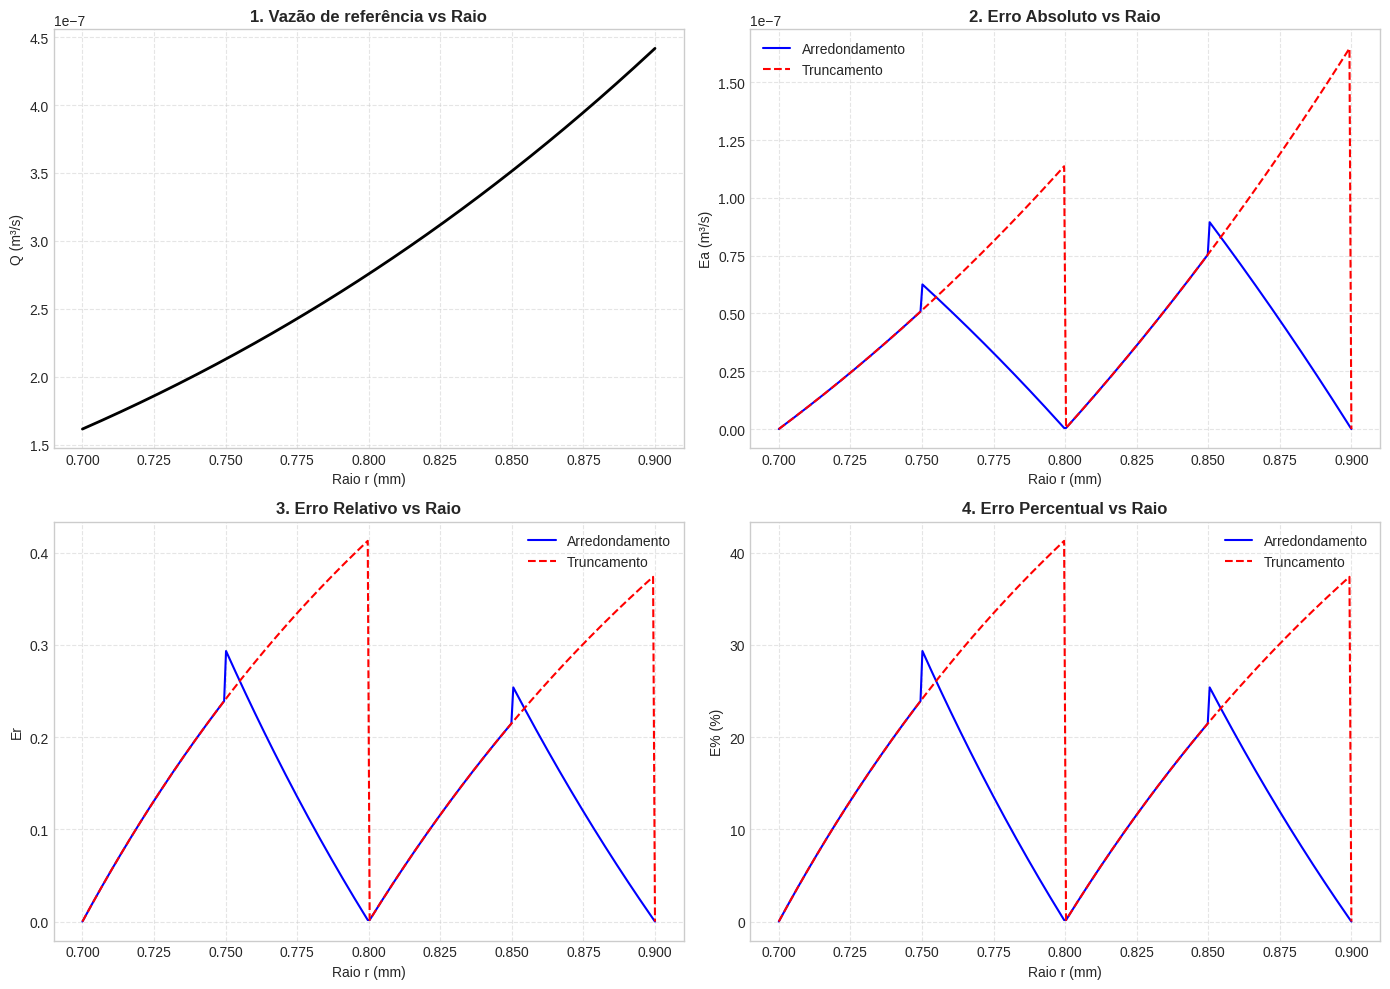

In [20]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

# Configuração visual padrão
plt.style.use("seaborn-v0_8-whitegrid")

# DADOS
r = 0.80  # mm
L = 0.20  # m
mu = 3.5e-3  # Pa.s
dp = 1200  # Pa

# Conversão do raio para metros
r_m = r / 1000

# FUNÇÃO DE HAGEN-POISEUILLE
def vazao(r, mu, dp, L):
    return (np.pi * r**4 * dp) / (8 * mu * L)

# VALOR DE REFERÊNCIA
Q_ref = vazao(r_m, mu, dp, L)

print("=" * 60)
print(f"{'VALOR DE REFERÊNCIA':^60}")
print("=" * 60)
print(f"Q referência = {Q_ref:.6e} m³/s")
print(f"Q referência = {Q_ref * 1e6:.4f} mL/s\n")

# FUNÇÃO PARA CALCULAR ERROS
def calcular_erros(Q):
    Ea = abs(Q_ref - Q)
    Er = Ea / abs(Q_ref)
    Epercentual = 100 * Er
    return Ea, Er, Epercentual

# C.1 - PRECISÃO DAS VARIÁVEIS
cenarios = []

# 1. Referência
cenarios.append({"Cenário": "1. Referência", "Q (m³/s)": Q_ref, "Ea": 0, "Er": 0, "E%": 0})

# 2. r
r_arred = round(r, 1)
r_trunc = math.trunc(r * 10) / 10
cenarios.append({"Cenário": "2. r arredondado", "Q (m³/s)": vazao(r_arred/1000, mu, dp, L), **dict(zip(["Ea", "Er", "E%"], calcular_erros(vazao(r_arred/1000, mu, dp, L))))})
cenarios.append({"Cenário": "2. r truncado", "Q (m³/s)": vazao(r_trunc/1000, mu, dp, L), **dict(zip(["Ea", "Er", "E%"], calcular_erros(vazao(r_trunc/1000, mu, dp, L))))})

# 3. mu
mu_arred = round(mu, 3)
mu_trunc = math.trunc(mu * 1000) / 1000
cenarios.append({"Cenário": "3. mu arredondado", "Q (m³/s)": vazao(r_m, mu_arred, dp, L), **dict(zip(["Ea", "Er", "E%"], calcular_erros(vazao(r_m, mu_arred, dp, L))))})
cenarios.append({"Cenário": "3. mu truncado", "Q (m³/s)": vazao(r_m, mu_trunc, dp, L), **dict(zip(["Ea", "Er", "E%"], calcular_erros(vazao(r_m, mu_trunc, dp, L))))})

# 4. dp
dp_arred = round(dp / 100) * 100
dp_trunc = math.trunc(dp / 100) * 100
cenarios.append({"Cenário": "4. dp arredondado", "Q (m³/s)": vazao(r_m, mu, dp_arred, L), **dict(zip(["Ea", "Er", "E%"], calcular_erros(vazao(r_m, mu, dp_arred, L))))})
cenarios.append({"Cenário": "4. dp truncado", "Q (m³/s)": vazao(r_m, mu, dp_trunc, L), **dict(zip(["Ea", "Er", "E%"], calcular_erros(vazao(r_m, mu, dp_trunc, L))))})

# 5. Todas
cenarios.append({"Cenário": "5. Todas arredondadas", "Q (m³/s)": vazao(r_arred/1000, mu_arred, dp_arred, L), **dict(zip(["Ea", "Er", "E%"], calcular_erros(vazao(r_arred/1000, mu_arred, dp_arred, L))))})
cenarios.append({"Cenário": "5. Todas truncadas", "Q (m³/s)": vazao(r_trunc/1000, mu_trunc, dp_trunc, L), **dict(zip(["Ea", "Er", "E%"], calcular_erros(vazao(r_trunc/1000, mu_trunc, dp_trunc, L))))})

# FORMATAÇÃO VISUAL DA TABELA
df = pd.DataFrame(cenarios)
df_formatado = df.copy()
df_formatado["Q (m³/s)"] = df["Q (m³/s)"].map("{:.4e}".format)
df_formatado["Ea"] = df["Ea"].map("{:.4e}".format)
df_formatado["Er"] = df["Er"].map("{:.4e}".format)
df_formatado["E%"] = df["E%"].map("{:.4f} %".format)

print("=" * 95)
print(f"{'TABELA C.1 - ANÁLISE DE PRECISÃO E PROPAGAÇÃO DE ERROS':^95}")
print("=" * 95)
try:
    # Cria uma tabela text-based com bordas estilo grade (funciona muito bem no Colab/Jupyter)
    print(df_formatado.to_markdown(index=False, tablefmt="grid", stralign="center", numalign="center"))
except ImportError:
    # Fallback seguro caso a biblioteca tabulate não esteja instalada
    print(df_formatado.to_string(index=False, justify="center"))
print("=" * 95 + "\n")

# C.2 - SENSIBILIDADE AO RAIO
raios = np.linspace(0.70, 0.90, 300)

Q_ref_list, Ea_arr_list, Er_arr_list, Ep_arr_list, Ea_tr_list, Er_tr_list, Ep_tr_list = [], [], [], [], [], [], []

for r_val in raios:
    q_ref_v = vazao(r_val / 1000, mu, dp, L)
    q_arr_v = vazao(round(r_val, 1) / 1000, mu, dp, L)
    q_tr_v = vazao((math.trunc(r_val * 10) / 10) / 1000, mu, dp, L)

    Q_ref_list.append(q_ref_v)

    # Arredondamento
    Ea_arr_list.append(abs(q_ref_v - q_arr_v))
    Er_arr_list.append(abs(q_ref_v - q_arr_v) / q_ref_v)
    Ep_arr_list.append((abs(q_ref_v - q_arr_v) / q_ref_v) * 100)

    # Truncamento
    Ea_tr_list.append(abs(q_ref_v - q_tr_v))
    Er_tr_list.append(abs(q_ref_v - q_tr_v) / q_ref_v)
    Ep_tr_list.append((abs(q_ref_v - q_tr_v) / q_ref_v) * 100)

# GRÁFICOS (Painel 2x2)
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0, 0].plot(raios, Q_ref_list, 'k-', linewidth=2)
axs[0, 0].set_title("1. Vazão de referência vs Raio", fontsize=12, fontweight='bold')
axs[0, 0].set_ylabel("Q (m³/s)")

axs[0, 1].plot(raios, Ea_arr_list, 'b-', label='Arredondamento')
axs[0, 1].plot(raios, Ea_tr_list, 'r--', label='Truncamento')
axs[0, 1].set_title("2. Erro Absoluto vs Raio", fontsize=12, fontweight='bold')
axs[0, 1].set_ylabel("Ea (m³/s)")
axs[0, 1].legend()

axs[1, 0].plot(raios, Er_arr_list, 'b-', label='Arredondamento')
axs[1, 0].plot(raios, Er_tr_list, 'r--', label='Truncamento')
axs[1, 0].set_title("3. Erro Relativo vs Raio", fontsize=12, fontweight='bold')
axs[1, 0].set_ylabel("Er")
axs[1, 0].legend()

axs[1, 1].plot(raios, Ep_arr_list, 'b-', label='Arredondamento')
axs[1, 1].plot(raios, Ep_tr_list, 'r--', label='Truncamento')
axs[1, 1].set_title("4. Erro Percentual vs Raio", fontsize=12, fontweight='bold')
axs[1, 1].set_ylabel("E% (%)")
axs[1, 1].legend()

for ax in axs.flat:
    ax.set_xlabel("Raio r (mm)")
    ax.grid(True, alpha=0.5, linestyle='--')

plt.tight_layout()
plt.show()

**5) C.2 Explique por que o erro no raio é amplificado na vazão. Relacione sua resposta ao expoente quatro.**


O erro no raio é amplificado na vazão porque, na equação de Hagen–Poiseuille, o raio aparece elevado à quarta potência. Assim, pequenas variações no raio provocam variações muito maiores na vazão. Por exemplo, se o raio sofrer uma variação de 10%, a vazão não sofrerá apenas uma variação de 10%, pois depende de \(r^4\). Para um aumento de 10% no raio, a vazão é multiplicada por \(1,1^4=1,4641\), correspondendo a aproximadamente 46,4% de aumento. Isso mostra que a vazão é altamente sensível a pequenas alterações geométricas do tubo. Em um nanocateter, essa sensibilidade é ainda mais relevante, pois pequenas diferenças nas dimensões do canal podem produzir alterações significativas no escoamento.

Uma observação sobre o gráfico

No intervalo pedido:

$$ 0,70\leq r\leq0,90\text{ mm} $$

você deve perceber que a curva de \(Q\) cresce bem rapidamente conforme o raio aumenta.

Isso ocorre porque:

$$ Q\propto r^4 $$

Por exemplo, comparando \(0,70\) mm com \(0,90\) mm:

$$ \frac{Q_{0,90}}{Q_{0,70}} = \left(\frac{0,90}{0,70}\right)^4 \approx2,73 $$

Ou seja, aumentar o raio de 0,70 para 0,90 mm — uma mudança de apenas 28,6% — produz uma vazão aproximadamente 2,73 vezes maior. Isso é exatamente o fenômeno que a atividade quer que você observe.

**6) Parte D – escoamento em um nanocateter**

                    VAZÃO DE REFERÊNCIA                     
Raio: 50.0 nm
Comprimento: 10.0 um
Viscosidade: 3.50e-03 Pa.s
Queda de pressão: 5000 Pa
Vazão de referência Q(r): 3.506242e-19 m³/s



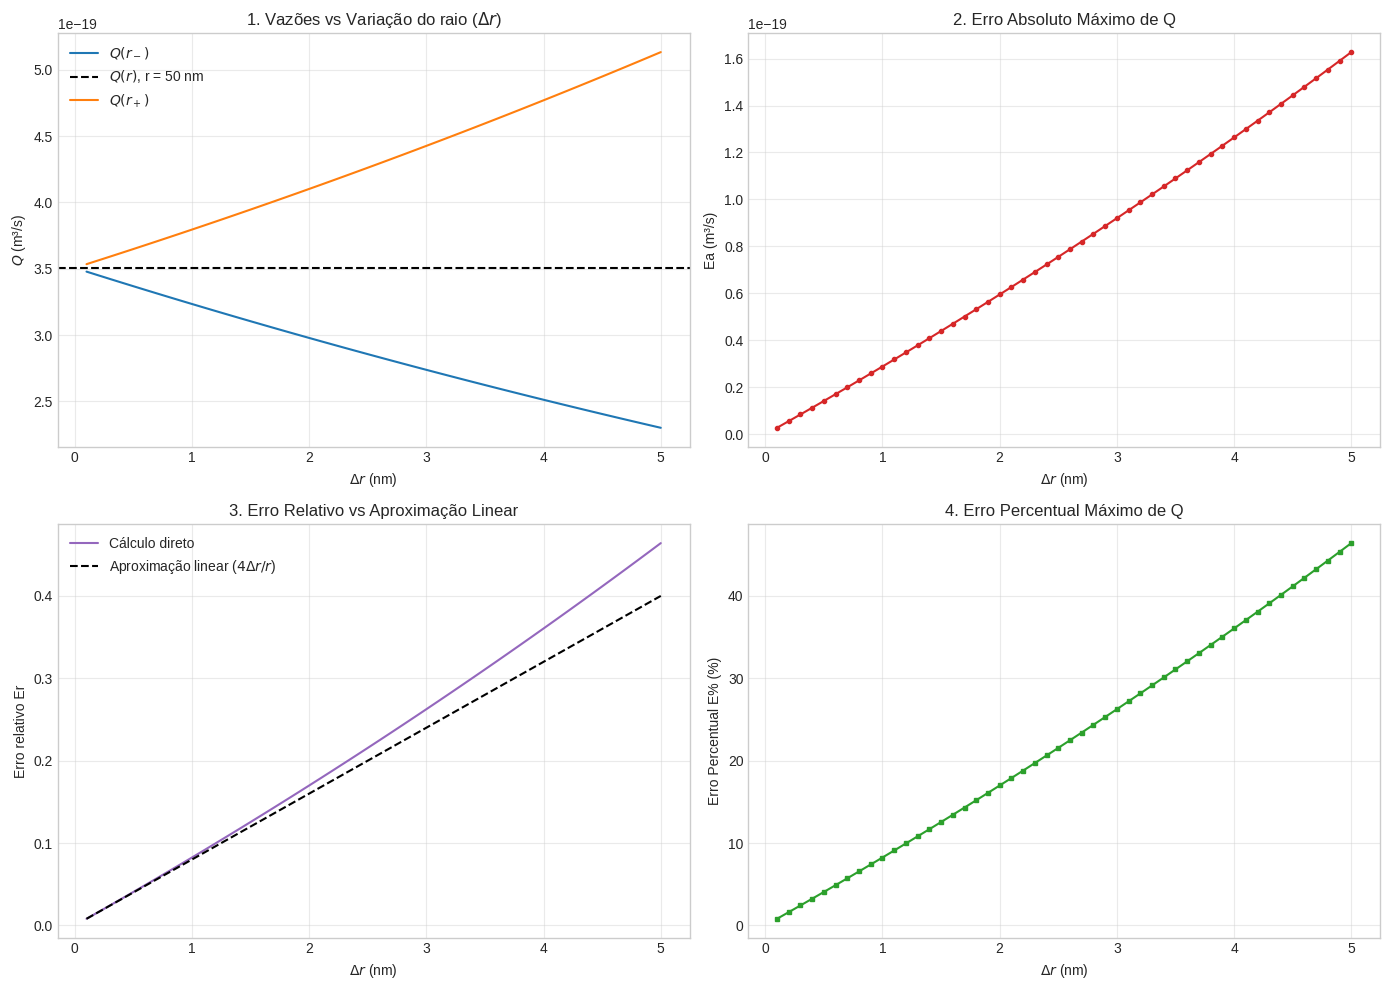

              D.2 - COMPARAÇÃO DE PRECISÃO COMPUTACIONAL              
FLOAT32 | eps = 1.1921e-07 | r^4 = 6.250000e-30 | Q = 3.5062423237e-19
FLOAT64 | eps = 2.2204e-16 | r^4 = 6.250000e-30 | Q = 3.5062418009e-19
----------------------------------------------------------------------
Diferença absoluta: 5.228628e-26 m³/s
Diferença relativa: 1.491234e-07



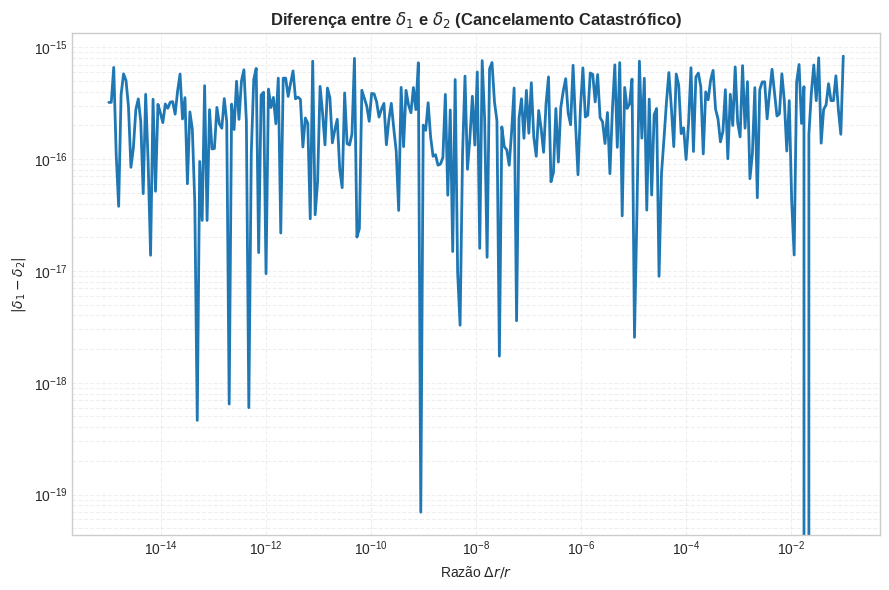

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configuração visual padrão para os gráficos
plt.style.use("seaborn-v0_8-whitegrid")

# ==========================================
# PARÂMETROS DO MODELO - NANOCATETER
# ==========================================
r = 50.0e-9         # Raio (50 nm) em metros
L = 10.0e-6         # Comprimento (10 um) em metros
mu = 3.5e-3         # Viscosidade dinâmica em Pa.s
delta_p = 5000.0    # Queda de pressão em Pa

def calcular_q(raio):
    return (np.pi * (raio ** 4) * delta_p) / (8 * mu * L)

q_ref = calcular_q(r)

print("=" * 60)
print(f"{'VAZÃO DE REFERÊNCIA':^60}")
print("=" * 60)
print(f"Raio: {r * 1e9:.1f} nm")
print(f"Comprimento: {L * 1e6:.1f} um")
print(f"Viscosidade: {mu:.2e} Pa.s")
print(f"Queda de pressão: {delta_p:.0f} Pa")
print(f"Vazão de referência Q(r): {q_ref:.6e} m³/s\n")


# ==========================================
# D.1 - ERRO GEOMÉTRICO E SENSIBILIDADE
# ==========================================
# Variações de raio: 0.1 até 5.0 nm
delta_r_vals = np.arange(0.1e-9, 5.1e-9, 0.1e-9)

r_minus = r - delta_r_vals
r_plus = r + delta_r_vals

q_minus = calcular_q(r_minus)
q_plus = calcular_q(r_plus)

# Erros máximos (o r+ sempre gera o maior erro absoluto devido à potência r^4)
erro_abs_max = np.maximum(np.abs(q_ref - q_minus), np.abs(q_ref - q_plus))
erro_rel_max = erro_abs_max / q_ref
erro_perc_max = 100.0 * erro_rel_max

# Aproximação linear: dQ/Q ≈ 4 * dr/r
erro_rel_linear = 4.0 * (delta_r_vals / r)

# GRÁFICOS D.1
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0, 0].plot(delta_r_vals * 1e9, q_minus, label=r"$Q(r_-)$", color="tab:blue")
axs[0, 0].axhline(q_ref, color="black", linestyle="--", label=r"$Q(r)$, r = 50 nm")
axs[0, 0].plot(delta_r_vals * 1e9, q_plus, label=r"$Q(r_+)$", color="tab:orange")
axs[0, 0].set_title(r"1. Vazões vs Variação do raio ($\Delta r$)")
axs[0, 0].set_ylabel(r"$Q$ (m³/s)")
axs[0, 0].legend()

axs[0, 1].plot(delta_r_vals * 1e9, erro_abs_max, color="tab:red", marker="o", markersize=3)
axs[0, 1].set_title("2. Erro Absoluto Máximo de Q")
axs[0, 1].set_ylabel("Ea (m³/s)")

axs[1, 0].plot(delta_r_vals * 1e9, erro_rel_max, label="Cálculo direto", color="tab:purple")
axs[1, 0].plot(delta_r_vals * 1e9, erro_rel_linear, label=r"Aproximação linear ($4\Delta r/r$)", linestyle="--", color="black")
axs[1, 0].set_title("3. Erro Relativo vs Aproximação Linear")
axs[1, 0].set_ylabel("Erro relativo Er")
axs[1, 0].legend()

axs[1, 1].plot(delta_r_vals * 1e9, erro_perc_max, color="tab:green", marker="s", markersize=3)
axs[1, 1].set_title("4. Erro Percentual Máximo de Q")
axs[1, 1].set_ylabel("Erro Percentual E% (%)")

for ax in axs.flat:
    ax.set_xlabel(r"$\Delta r$ (nm)")
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


# ==========================================
# D.2 - PRECISÃO COMPUTACIONAL
# ==========================================
# Precisão Simples (float32)
r_f32 = np.float32(r)
q_f32 = (np.float32(np.pi) * (r_f32**4) * np.float32(delta_p)) / (np.float32(8.0) * np.float32(mu) * np.float32(L))

# Precisão Dupla (float64)
r_f64 = np.float64(r)
q_f64 = (np.float64(np.pi) * (r_f64**4) * np.float64(delta_p)) / (np.float64(8.0) * np.float64(mu) * np.float64(L))

diff_abs_q = np.abs(np.float64(q_f32) - q_f64)
diff_rel_q = diff_abs_q / np.abs(q_f64)

print("=" * 70)
print(f"{'D.2 - COMPARAÇÃO DE PRECISÃO COMPUTACIONAL':^70}")
print("=" * 70)
print(f"FLOAT32 | eps = {np.finfo(np.float32).eps:.4e} | r^4 = {r_f32**4:.6e} | Q = {q_f32:.10e}")
print(f"FLOAT64 | eps = {np.finfo(np.float64).eps:.4e} | r^4 = {r_f64**4:.6e} | Q = {q_f64:.10e}")
print("-" * 70)
print(f"Diferença absoluta: {diff_abs_q:.6e} m³/s")
print(f"Diferença relativa: {diff_rel_q:.6e}\n")


# ==========================================
# CANCELAMENTO CATASTRÓFICO (Análise Log-Log)
# ==========================================
fracoes_dr = np.logspace(-15, -1, 300)
delta_r_arr = fracoes_dr * r

# Método 1 (Direto - Equação 6)
delta_1 = (calcular_q(r + delta_r_arr) - calcular_q(r)) / calcular_q(r)
# Método 2 (Analítico - Equação 7)
delta_2 = (1.0 + fracoes_dr)**4 - 1.0

diferenca_cancelamento = np.abs(delta_1 - delta_2)

plt.figure(figsize=(9, 6))
plt.plot(fracoes_dr, diferenca_cancelamento, color="tab:blue", marker="", linewidth=2)
plt.yscale("log")
plt.xscale("log")
plt.title(r"Diferença entre $\delta_1$ e $\delta_2$ (Cancelamento Catastrófico)", fontweight='bold')
plt.xlabel(r"Razão $\Delta r / r$")
plt.ylabel(r"$|\delta_1-\delta_2|$")
plt.grid(True, which="both", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

**6) D.2 Precisão computacional**

Ao calcular a variação da vazão por $\delta_1 = \frac{Q(r+\Delta r) - Q(r)}{Q(r)}$ para valores de $\Delta r/r$ muito pequenos (próximos à precisão da máquina, $10^{-15}$), ocorre o fenômeno numérico conhecido como cancelamento catastrófico. Como os números $Q(r+\Delta r)$ e $Q(r)$ são quase idênticos, a subtração apaga os algarismos significativos comuns, deixando apenas "lixo" de arredondamento. A formulação $\delta_2 = \left(1+\frac{\Delta r}{r}\right)^4 - 1$ adia esse problema matemático por lidar com variações menores em torno do número 1. O gráfico log-log comprova que, à medida que $\Delta r/r$ diminui, a discrepância entre as fórmulas explode devido às limitações aritméticas do tipo float64.

**6) D.3 Fenômeno físico**

Ao reduzirmos o canal para a escala nanométrica (r = 50 nm), a razão entre a superfície de contato e o volume de fluido aumenta drasticamente. Em micro/nanofluidica, a maior parte do fluido passa a interagir diretamente com as paredes do tubo, onde as forças de cisalhamento e viscosidade são máximas devido à condição de não escorregamento (velocidade nula na parede). Por essa razão, os efeitos viscosos governam o sistema (baixo número de Reynolds), justificando o fato de que qualquer defeito microscópico (uma variação de 1 nm) altera radicalmente o comportamento de toda a vazão, tornando incertezas de projeto fisicamente críticas, independentemente de quantas casas decimais a matemática utilize.

**7) Parte E – síntese visual**

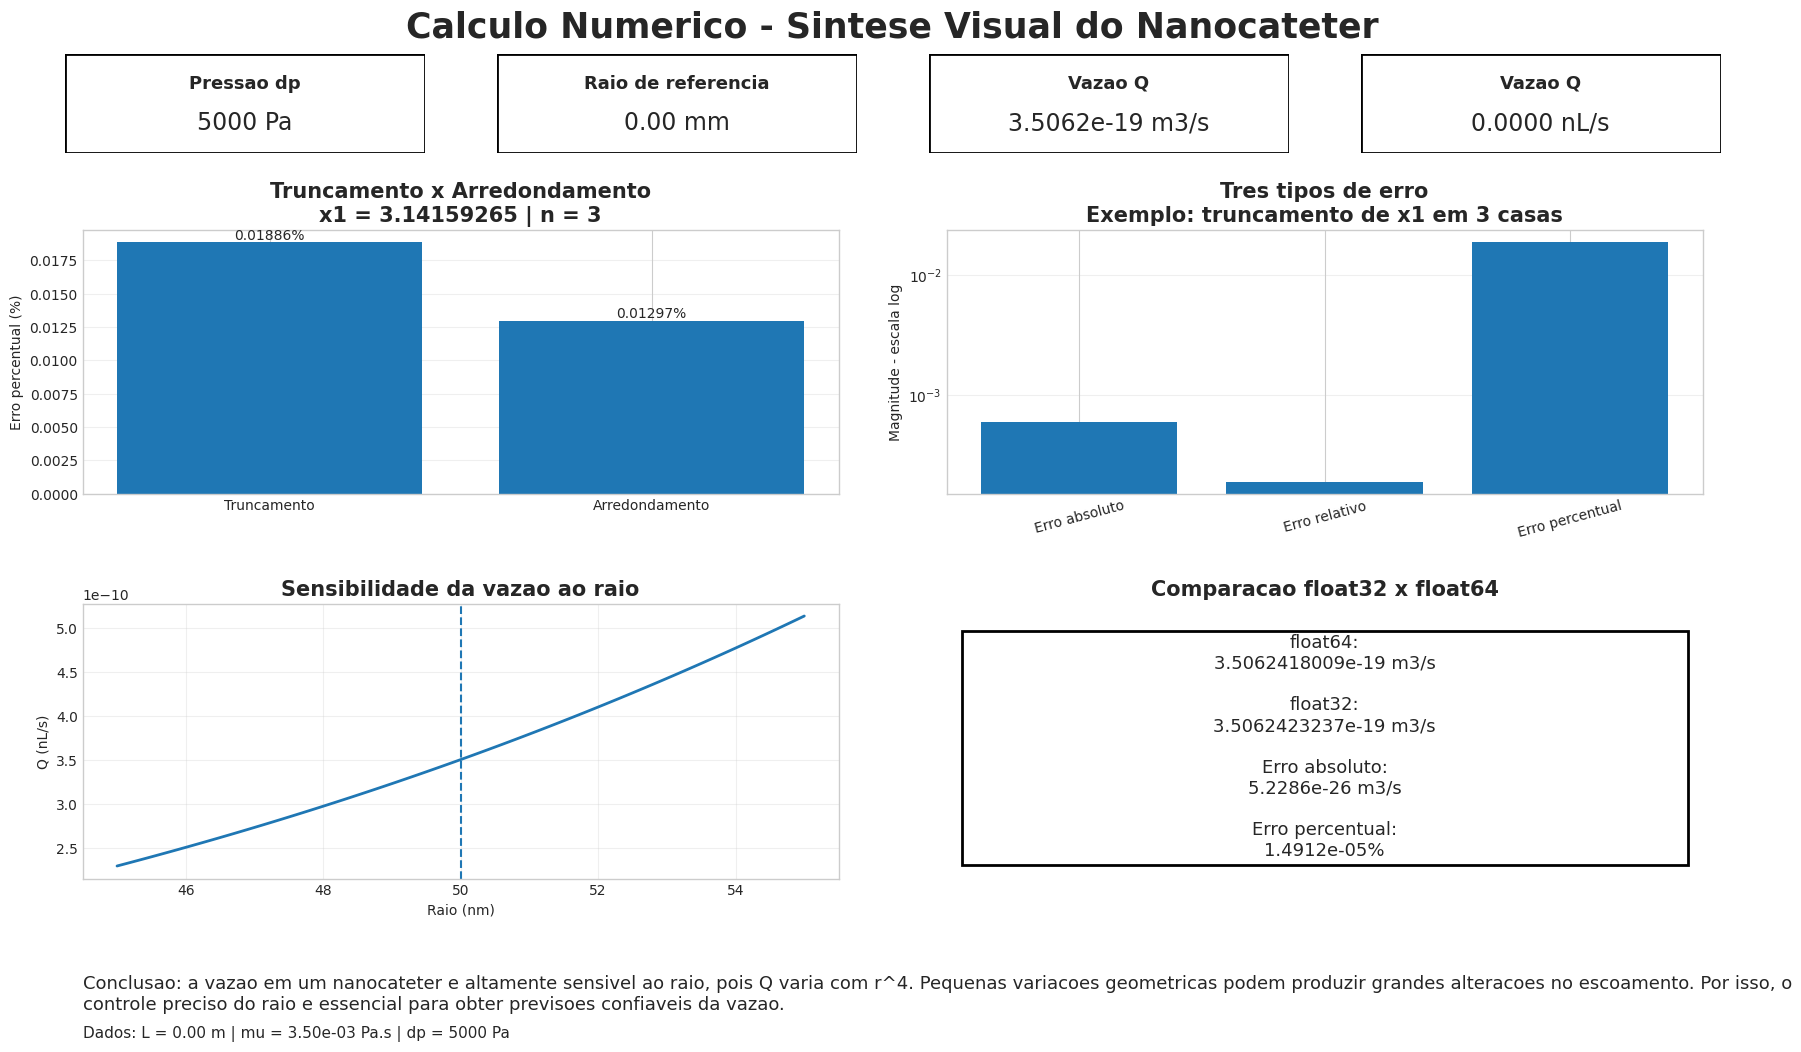

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# CONFIGURACAO
plt.rcParams["font.family"] = "DejaVu Sans"

# DADOS PARA O NANOCATETER
L = 10.0e-6      # 10 micrometros
mu = 3.5e-3      # Pa.s
dp = 5000.0      # Pa
r_m = 50.0e-9    # 50 nm
r_mm = r_m * 1000 # Mantido apenas para não quebrar a formatação do seu cartão

# FUNCAO DE HAGEN-POISEUILLE
def vazao(r, mu, dp, L):
    return (np.pi * r**4 * dp) / (8 * mu * L)

# Vazao de referencia
Q_ref = vazao(r_m, mu, dp, L)

# TRUNCAMENTO X ARREDONDAMENTO
x = 3.14159265
n = 3

x_trunc = np.trunc(x * 10**n) / 10**n
x_arred = round(x, n)

# Erro do truncamento
Ea_trunc = abs(x - x_trunc)
Er_trunc = Ea_trunc / abs(x)
Ep_trunc = 100 * Er_trunc

# Erro do arredondamento
Ea_arred = abs(x - x_arred)
Er_arred = Ea_arred / abs(x)
Ep_arred = 100 * Er_arred

# TRES TIPOS DE ERRO
erro_absoluto = Ea_trunc
erro_relativo = Er_trunc
erro_percentual = Ep_trunc

# SENSIBILIDADE AO RAIO
raios_nm = np.linspace(45, 55, 101)
raios_m = raios_nm * 1e-9

Q_raios = vazao(raios_m, mu, dp, L)

# FLOAT32 X FLOAT64
def vazao_float(r, mu, dp, L, dtype):
    r = dtype(r)
    mu = dtype(mu)
    dp = dtype(dp)
    L = dtype(L)

    return (
        dtype(np.pi) * r**dtype(4) * dp
        /
        (dtype(8) * mu * L)
    )

Q64 = vazao_float(50e-9, mu, dp, L, np.float64)
Q32 = vazao_float(50e-9, mu, dp, L, np.float32)

erro_float_absoluto = abs(Q64 - Q32)
erro_float_percentual = (100 * erro_float_absoluto / abs(Q64))


# CRIAR FIGURA
fig = plt.figure(figsize=(18, 11), dpi=100)
fig.patch.set_facecolor("white")

# TITULO
fig.suptitle(
    "Calculo Numerico - Sintese Visual do Nanocateter",
    fontsize=25,
    fontweight="bold",
    y=0.97
)

# CARTOES
cartoes = [
    ("Pressao dp", f"{dp:.0f} Pa"),
    ("Raio de referencia", f"{r_mm:.2f} mm"),
    ("Vazao Q", f"{Q_ref:.4e} m3/s"),
    ("Vazao Q", f"{Q_ref * 1e9:.4f} nL/s")
]

posicoes = [0.04, 0.28, 0.52, 0.76]

for ((titulo, valor), xpos) in zip(cartoes, posicoes):
    ax = fig.add_axes([xpos, 0.84, 0.20, 0.09])
    ax.axis("off")
    ax.add_patch(Rectangle((0, 0), 1, 1, fill=False, linewidth=2))

    ax.text(0.5, 0.70, titulo, ha="center", va="center", fontsize=13, fontweight="bold")
    ax.text(0.5, 0.30, valor, ha="center", va="center", fontsize=17)


# GRAFICO 1 - TRUNCAMENTO X ARREDONDAMENTO
ax1 = fig.add_axes([0.05, 0.53, 0.42, 0.24])
metodos = ["Truncamento", "Arredondamento"]
erros = [Ep_trunc, Ep_arred]

ax1.bar(metodos, erros)
ax1.set_title("Truncamento x Arredondamento\nx1 = 3.14159265 | n = 3", fontsize=15, fontweight="bold")
ax1.set_ylabel("Erro percentual (%)")
ax1.grid(axis="y", alpha=0.3)

for i, valor in enumerate(erros):
    ax1.text(i, valor, f"{valor:.5f}%", ha="center", va="bottom")


# GRAFICO 2 - TRES TIPOS DE ERRO
ax2 = fig.add_axes([0.53, 0.53, 0.42, 0.24])
tipos = ["Erro absoluto", "Erro relativo", "Erro percentual"]
valores = [erro_absoluto, erro_relativo, erro_percentual]

ax2.bar(tipos, valores)
ax2.set_yscale("log")
ax2.set_title("Tres tipos de erro\nExemplo: truncamento de x1 em 3 casas", fontsize=15, fontweight="bold")
ax2.set_ylabel("Magnitude - escala log")
ax2.tick_params(axis="x", rotation=15)
ax2.grid(axis="y", alpha=0.3)


# GRAFICO 3 - SENSIBILIDADE DE Q AO RAIO
ax3 = fig.add_axes([0.05, 0.18, 0.42, 0.25])
ax3.plot(raios_nm, Q_raios * 1e9, linewidth=2)
ax3.axvline(50, linestyle="--", linewidth=1.5)
ax3.set_title("Sensibilidade da vazao ao raio", fontsize=15, fontweight="bold")
ax3.set_xlabel("Raio (nm)")
ax3.set_ylabel("Q (nL/s)")
ax3.grid(True, alpha=0.3)


# BLOCO FLOAT32 X FLOAT64
ax4 = fig.add_axes([0.53, 0.18, 0.42, 0.25])
ax4.axis("off")
ax4.add_patch(Rectangle((0.02, 0.05), 0.96, 0.85, fill=False, linewidth=2))
ax4.set_title("Comparacao float32 x float64", fontsize=15, fontweight="bold")

texto = (
    f"float64:\n{Q64:.10e} m3/s\n\n"
    f"float32:\n{Q32:.10e} m3/s\n\n"
    f"Erro absoluto:\n{erro_float_absoluto:.4e} m3/s\n\n"
    f"Erro percentual:\n{erro_float_percentual:.4e}%"
)
ax4.text(0.5, 0.48, texto, ha="center", va="center", fontsize=13)


# CONCLUSAO & DADOS
conclusao = (
    "Conclusao: a vazao em um nanocateter e altamente sensivel ao raio, "
    "pois Q varia com r^4. Pequenas variacoes geometricas podem produzir "
    "grandes alteracoes no escoamento. Por isso, o controle preciso do "
    "raio e essencial para obter previsoes confiaveis da vazao."
)

fig.text(0.05, 0.075, conclusao, fontsize=13, wrap=True, va="center")
fig.text(0.05, 0.035, f"Dados: L = {L:.2f} m | mu = {mu:.2e} Pa.s | dp = {dp:.0f} Pa", fontsize=11)

# ==========================================================
# EXIBIR DIRETAMENTE NO COLAB
# ==========================================================
plt.show()

**8) GIF demonstrativo**

GIF gerado com sucesso! Arquivo salvo como: nanocateter_animacao.gif


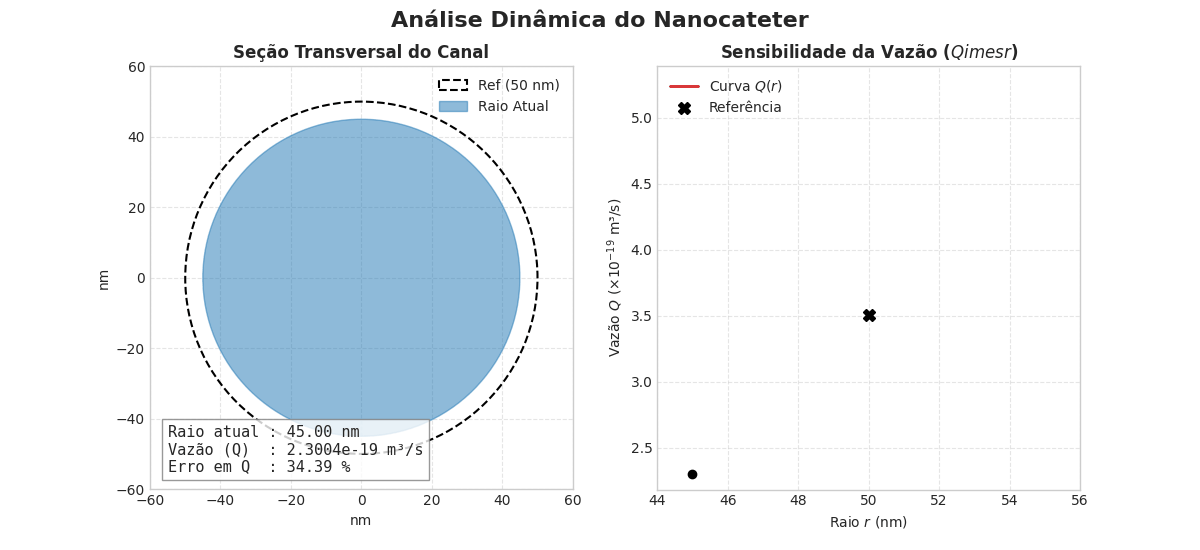

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Circle
from IPython.display import Image, display

# ==========================================
# PARÂMETROS FÍSICOS DO NANOCATETER
# ==========================================
L = 10.0e-6        # Comprimento (10 um) em metros
mu = 3.5e-3        # Viscosidade dinâmica em Pa.s
dp = 5000.0        # Queda de pressão em Pa
r_ref = 50.0e-9    # Raio de referência (50 nm)

def calcular_vazao(r):
    return (np.pi * (r**4) * dp) / (8 * mu * L)

Q_ref = calcular_vazao(r_ref)

# ==========================================
# CONFIGURAÇÃO DOS DADOS DO GIF
# ==========================================
num_frames = 50
raios_nm = np.linspace(45, 55, num_frames)
raios_m = raios_nm * 1e-9
vazoes = calcular_vazao(raios_m)

# Erros percentuais
erros_perc = 100 * np.abs(vazoes - Q_ref) / Q_ref

# ==========================================
# CONFIGURAÇÃO DA FIGURA
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5), dpi=100)
fig.suptitle('Análise Dinâmica do Nanocateter', fontsize=16, fontweight='bold')

# --- Painel Esquerdo: Seção Transversal ---
ax1.set_aspect('equal')
ax1.set_xlim(-60, 60)
ax1.set_ylim(-60, 60)
ax1.set_title('Seção Transversal do Canal', fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.set_xlabel('nm')
ax1.set_ylabel('nm')

# Círculo de referência (50 nm) - fixo
circ_ref = Circle((0, 0), 50, fill=False, edgecolor='black', linestyle='--', linewidth=1.5, label='Ref (50 nm)')
ax1.add_patch(circ_ref)

# Círculo dinâmico
circ_dinamico = Circle((0, 0), raios_nm[0], fill=True, color='tab:blue', alpha=0.5, label='Raio Atual')
ax1.add_patch(circ_dinamico)
ax1.legend(loc='upper right')

# Textos de informação na tela
info_text = ax1.text(-55, -55, '', fontsize=11, family='monospace',
                     bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

# --- Painel Direito: Curva Q x r ---
ax2.set_xlim(44, 56)
# Escalonando Q para umidades mais legíveis no gráfico (10^-19)
ax2.set_ylim(min(vazoes)*1e19 * 0.95, max(vazoes)*1e19 * 1.05)
ax2.set_title('Sensibilidade da Vazão ($Q \times r$)', fontweight='bold')
ax2.set_xlabel('Raio $r$ (nm)')
ax2.set_ylabel('Vazão $Q$ ($\\times 10^{-19}$ m³/s)')
ax2.grid(True, linestyle='--', alpha=0.5)

# Linha e ponto dinâmicos
linha_q, = ax2.plot([], [], color='tab:red', linewidth=2, label='Curva $Q(r)$')
ponto_q, = ax2.plot([], [], 'ko', markersize=6)
ax2.plot(50, Q_ref*1e19, 'kX', markersize=8, label='Referência')
ax2.legend(loc='upper left')

# ==========================================
# FUNÇÃO DE ANIMAÇÃO
# ==========================================
def update(frame):
    # Atualiza o círculo
    r_atual = raios_nm[frame]
    circ_dinamico.set_radius(r_atual)

    # Atualiza a curva
    linha_q.set_data(raios_nm[:frame+1], vazoes[:frame+1] * 1e19)
    ponto_q.set_data([r_atual], [vazoes[frame] * 1e19])

    # Atualiza o texto com os cálculos exigidos
    Q_atual = vazoes[frame]
    erro_atual = erros_perc[frame]

    texto = (
        f"Raio atual : {r_atual:.2f} nm\n"
        f"Vazão (Q)  : {Q_atual:.4e} m³/s\n"
        f"Erro em Q  : {erro_atual:.2f} %"
    )
    info_text.set_text(texto)

    return circ_dinamico, linha_q, ponto_q, info_text

plt.close() # Evita plotar quadro estático no Colab

# Gera a animação (50 quadros)
anim = FuncAnimation(fig, update, frames=num_frames, interval=100, blit=True)

# ==========================================
# SALVAR E EXIBIR
# ==========================================
arquivo_gif = 'nanocateter_animacao.gif'
anim.save(arquivo_gif, writer='pillow', fps=15)

print(f"GIF gerado com sucesso! Arquivo salvo como: {arquivo_gif}")

# Exibe diretamente na saída do Colab
display(Image(filename=arquivo_gif))

**9) Conclusão**

O estudo evidencia a importância da escolha adequada do método de aproximação e da manutenção da precisão decimal em cálculos matemáticos e estatísticos. A análise demonstra que o arredondamento é uma técnica sistematicamente superior ao truncamento, pois minimiza os erros absolutos e relativos ao escolher o valor representável mais próximo, limitando o erro máximo.  Na aplicação prática sobre medições de pressão arterial, constatou-se que a remoção prematura de casas decimais (através da representação inteira) distorce significativamente métricas de variabilidade, como a amplitude e o desvio-padrão, comprimindo a distribuição dos dados e mascarando pequenas flutuações.  Adicionalmente, na análise de sensibilidade da vazão em tubos de pequeno diâmetro usando a equação de Hagen-Poiseuille, confirmou-se que erros nas medidas iniciais se propagam de forma não-linear. A variável do raio possui uma sensibilidade crítica devido à sua elevação à quarta potência ($r^4$); desta forma, pequenas variações numéricas (sejam por truncamento ou medição imprecisa) resultam em desvios desproporcionais e expressivos no cálculo final da vazão, exigindo alta fidelidade e precisão nas grandezas de entrada.

**Conclusão Geral em PNG**

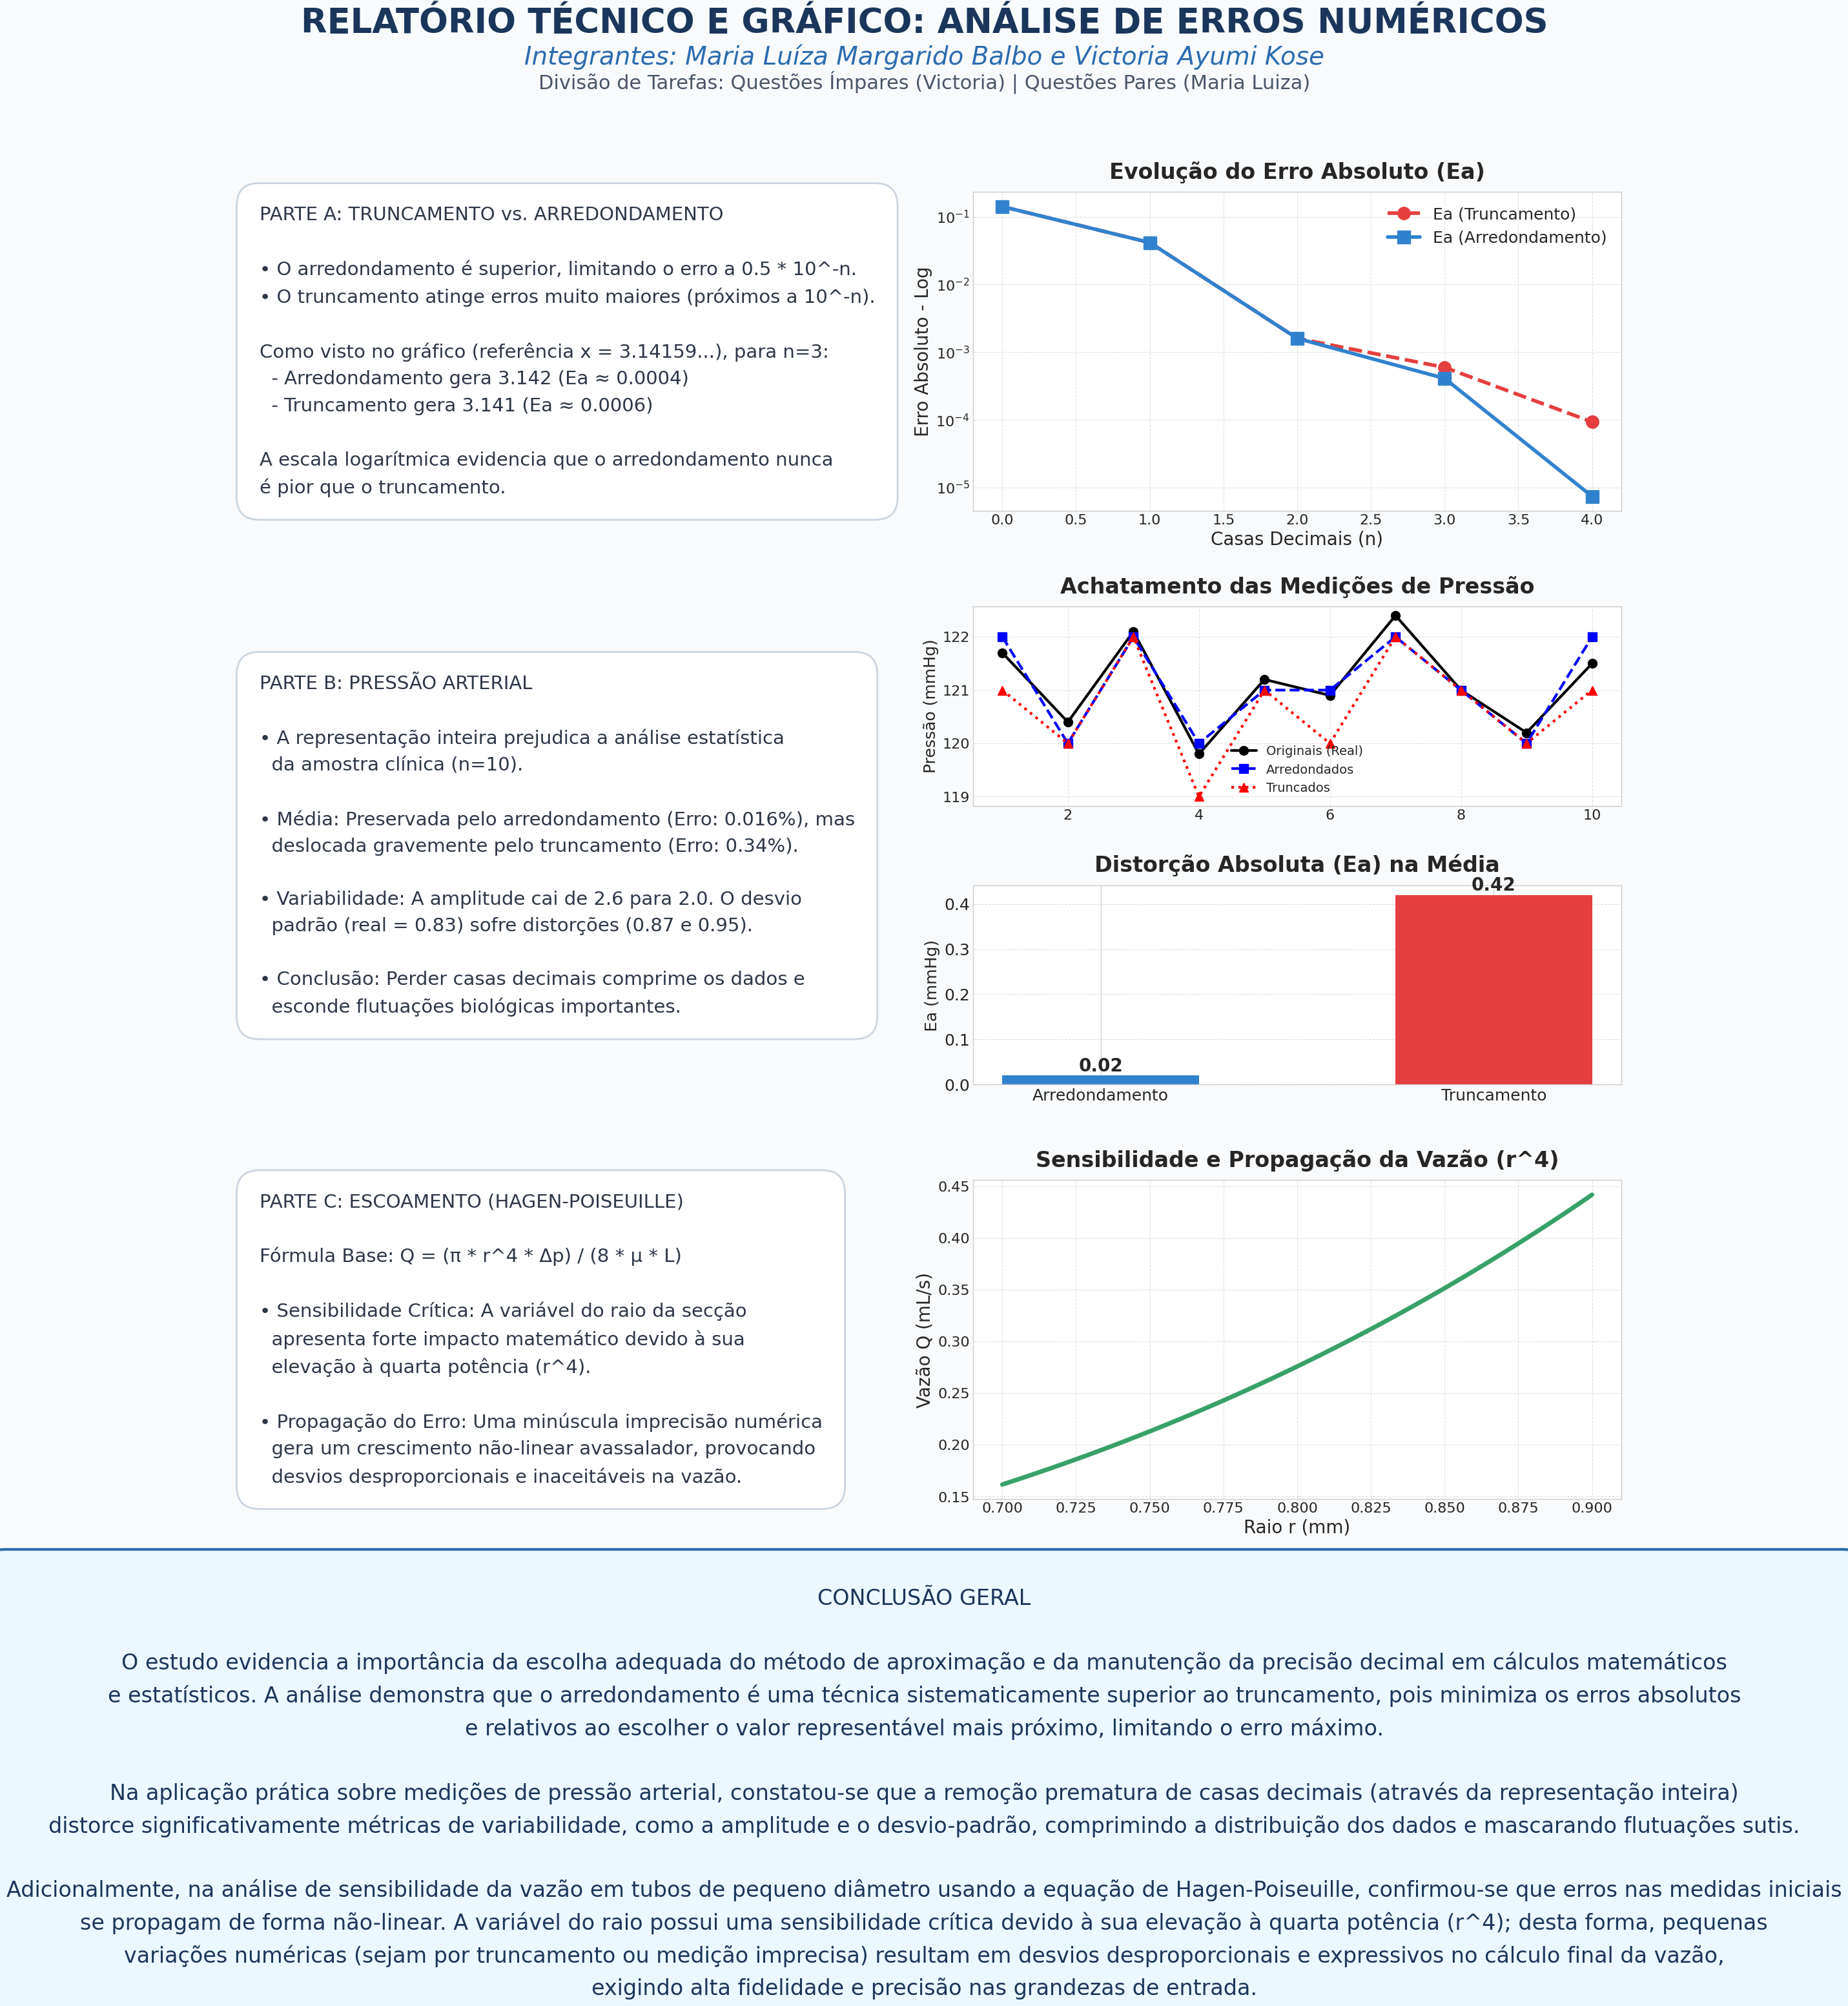

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec

# ==============================================================================
# CONFIGURAÇÃO "MASTER PRO MAX"
# Resolução de 2400 x 3400 pixels para alta fidelidade e visualização rica
# ==============================================================================
fig = plt.figure(figsize=(24, 34), dpi=100, facecolor='#F8FAFC')
gs = gridspec.GridSpec(5, 2, height_ratios=[0.5, 2, 3, 2, 2.5], wspace=0.15, hspace=0.3)

# 1. CABEÇALHO (Título e Nomes das Integrantes)
ax_head = fig.add_subplot(gs[0, :])
ax_head.axis('off')
ax_head.text(0.5, 0.8, 'RELATÓRIO TÉCNICO E GRÁFICO: ANÁLISE DE ERROS NUMÉRICOS',
             fontsize=38, fontweight='bold', ha='center', color='#1A365D')
ax_head.text(0.5, 0.4, 'Integrantes: Maria Luíza Margarido Balbo e Victoria Ayumi Kose',
             fontsize=28, style='italic', ha='center', color='#2B6CB0')
ax_head.text(0.5, 0.1, 'Divisão de Tarefas: Questões Ímpares (Victoria) | Questões Pares (Maria Luiza)',
             fontsize=22, ha='center', color='#4A5568')

box_style = dict(facecolor='#FFFFFF', edgecolor='#CBD5E0', boxstyle='round,pad=1.2', linewidth=2)

# ==========================================
# 2. PARTE A: TEXTO E GRÁFICO (Truncamento x Arredondamento)
# ==========================================
ax_ta = fig.add_subplot(gs[1, 0])
ax_ta.axis('off')
txt_a = ("PARTE A: TRUNCAMENTO vs. ARREDONDAMENTO\n\n"
         "• O arredondamento é superior, limitando o erro a 0.5 * 10^-n.\n"
         "• O truncamento atinge erros muito maiores (próximos a 10^-n).\n\n"
         "Como visto no gráfico (referência x = 3.14159...), para n=3:\n"
         "  - Arredondamento gera 3.142 (Ea ≈ 0.0004)\n"
         "  - Truncamento gera 3.141 (Ea ≈ 0.0006)\n\n"
         "A escala logarítmica evidencia que o arredondamento nunca\n"
         "é pior que o truncamento.")
ax_ta.text(0.05, 0.5, txt_a, fontsize=21, va='center', color='#2D3748', bbox=box_style, linespacing=1.6)

# Gráfico da Parte A
ax_pa = fig.add_subplot(gs[1, 1])
n = [0, 1, 2, 3, 4]
ea_t = [0.141593, 0.0415927, 0.00159265, 0.00059265, 9.265e-05]
ea_a = [0.141593, 0.0415927, 0.00159265, 0.00040735, 7.35e-06]
ax_pa.plot(n, ea_t, marker='o', ls='--', lw=4, ms=14, color='#E53E3E', label='Ea (Truncamento)')
ax_pa.plot(n, ea_a, marker='s', ls='-', lw=4, ms=14, color='#3182CE', label='Ea (Arredondamento)')
ax_pa.set_yscale('log')
ax_pa.set_title('Evolução do Erro Absoluto (Ea)', fontsize=24, fontweight='bold', pad=15)
ax_pa.set_xlabel('Casas Decimais (n)', fontsize=20)
ax_pa.set_ylabel('Erro Absoluto - Log', fontsize=20)
ax_pa.grid(True, ls='--', alpha=0.6)
ax_pa.legend(fontsize=18)
ax_pa.tick_params(labelsize=16)

# ==========================================
# 3. PARTE B: TEXTO E GRÁFICOS (Pressão Arterial)
# ==========================================
ax_tb = fig.add_subplot(gs[2, 0])
ax_tb.axis('off')
txt_b = ("PARTE B: PRESSÃO ARTERIAL\n\n"
         "• A representação inteira prejudica a análise estatística\n"
         "  da amostra clínica (n=10).\n\n"
         "• Média: Preservada pelo arredondamento (Erro: 0.016%), mas\n"
         "  deslocada gravemente pelo truncamento (Erro: 0.34%).\n\n"
         "• Variabilidade: A amplitude cai de 2.6 para 2.0. O desvio\n"
         "  padrão (real = 0.83) sofre distorções (0.87 e 0.95).\n\n"
         "• Conclusão: Perder casas decimais comprime os dados e \n"
         "  esconde flutuações biológicas importantes.")
ax_tb.text(0.05, 0.5, txt_b, fontsize=21, va='center', color='#2D3748', bbox=box_style, linespacing=1.6)

# Aninhando os gráficos de Pressão (Evolução e Barras)
gs_b = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[2, 1], hspace=0.4)

ax_pb1 = fig.add_subplot(gs_b[0, 0])
orig = np.array([121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5])
arr = np.floor(orig + 0.5)
trunc = np.trunc(orig)
x_b = np.arange(1, 11)
ax_pb1.plot(x_b, orig, 'k-o', lw=3, ms=10, label='Originais (Real)')
ax_pb1.plot(x_b, arr, 'b--s', lw=3, ms=10, label='Arredondados')
ax_pb1.plot(x_b, trunc, 'r:^', lw=3, ms=10, label='Truncados')
ax_pb1.set_title('Achatamento das Medições de Pressão', fontsize=24, fontweight='bold', pad=15)
ax_pb1.set_ylabel('Pressão (mmHg)', fontsize=18)
ax_pb1.grid(True, ls='--', alpha=0.6)
ax_pb1.legend(fontsize=14)
ax_pb1.tick_params(labelsize=16)

ax_pb2 = fig.add_subplot(gs_b[1, 0])
bars = ax_pb2.bar(['Arredondamento', 'Truncamento'], [0.02, 0.42], color=['#3182CE', '#E53E3E'], width=0.5)
ax_pb2.set_title('Distorção Absoluta (Ea) na Média', fontsize=24, fontweight='bold', pad=15)
ax_pb2.set_ylabel('Ea (mmHg)', fontsize=18)
ax_pb2.grid(axis='y', ls='--', alpha=0.6)
ax_pb2.tick_params(labelsize=18)
for bar in bars:
    yval = bar.get_height()
    ax_pb2.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval}', ha='center', fontsize=20, fontweight='bold')

# ==========================================
# 4. PARTE C: TEXTO E GRÁFICO (Hagen-Poiseuille)
# ==========================================
ax_tc = fig.add_subplot(gs[3, 0])
ax_tc.axis('off')
txt_c = ("PARTE C: ESCOAMENTO (HAGEN-POISEUILLE)\n\n"
         "Fórmula Base: Q = (π * r^4 * Δp) / (8 * μ * L)\n\n"
         "• Sensibilidade Crítica: A variável do raio da secção\n"
         "  apresenta forte impacto matemático devido à sua\n"
         "  elevação à quarta potência (r^4).\n\n"
         "• Propagação do Erro: Uma minúscula imprecisão numérica\n"
         "  gera um crescimento não-linear avassalador, provocando\n"
         "  desvios desproporcionais e inaceitáveis na vazão.")
ax_tc.text(0.05, 0.5, txt_c, fontsize=21, va='center', color='#2D3748', bbox=box_style, linespacing=1.6)

# Gráfico da Vazão
ax_pc = fig.add_subplot(gs[3, 1])
raios = np.linspace(0.7, 0.9, 100)
mu, dp, L = 3.5e-3, 1200, 0.20
vazao = (np.pi * (raios/1000)**4 * dp) / (8 * mu * L)
ax_pc.plot(raios, vazao * 1e6, '-', color='#38A169', lw=5)
ax_pc.set_title('Sensibilidade e Propagação da Vazão (r^4)', fontsize=24, fontweight='bold', pad=15)
ax_pc.set_xlabel('Raio r (mm)', fontsize=20)
ax_pc.set_ylabel('Vazão Q (mL/s)', fontsize=20)
ax_pc.grid(True, ls='--', alpha=0.6)
ax_pc.tick_params(labelsize=16)

# ==========================================
# 5. CONCLUSÃO GERAL
# ==========================================
ax_conc = fig.add_subplot(gs[4, :])
ax_conc.axis('off')
txt_conc = ("CONCLUSÃO GERAL\n\n"
            "O estudo evidencia a importância da escolha adequada do método de aproximação e da manutenção da precisão decimal em cálculos matemáticos\n"
            "e estatísticos. A análise demonstra que o arredondamento é uma técnica sistematicamente superior ao truncamento, pois minimiza os erros absolutos\n"
            "e relativos ao escolher o valor representável mais próximo, limitando o erro máximo.\n\n"
            "Na aplicação prática sobre medições de pressão arterial, constatou-se que a remoção prematura de casas decimais (através da representação inteira)\n"
            "distorce significativamente métricas de variabilidade, como a amplitude e o desvio-padrão, comprimindo a distribuição dos dados e mascarando flutuações sutis.\n\n"
            "Adicionalmente, na análise de sensibilidade da vazão em tubos de pequeno diâmetro usando a equação de Hagen-Poiseuille, confirmou-se que erros nas medidas iniciais\n"
            "se propagam de forma não-linear. A variável do raio possui uma sensibilidade crítica devido à sua elevação à quarta potência (r^4); desta forma, pequenas\n"
            "variações numéricas (sejam por truncamento ou medição imprecisa) resultam em desvios desproporcionais e expressivos no cálculo final da vazão,\n"
            "exigindo alta fidelidade e precisão nas grandezas de entrada.")

box_conc = dict(facecolor='#EBF8FF', edgecolor='#2B6CB0', boxstyle='round,pad=1.8', linewidth=3)
ax_conc.text(0.5, 0.5, txt_conc, fontsize=24, ha='center', va='center', color='#1A365D', bbox=box_conc, linespacing=1.6)

# ==========================================
# GERAÇÃO E SALVAMENTO
# ==========================================
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)
# Salva a imagem
plt.savefig('Master_Pro_Max_Relatorio.png', dpi=100, bbox_inches='tight')

# Mostra o preview
plt.show()

